# Importaçao de Blibliotecas

In [14]:
import os
import random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms, models

from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de Reprodutibilidade e Ambiente

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEMENTE_GLOBAL = 42

random.seed(SEMENTE_GLOBAL)
np.random.seed(SEMENTE_GLOBAL)
os.environ['PYTHONHASHSEED'] = str(SEMENTE_GLOBAL)

torch.manual_seed(SEMENTE_GLOBAL)
torch.cuda.manual_seed(SEMENTE_GLOBAL)
torch.cuda.manual_seed_all(SEMENTE_GLOBAL)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Rodando na: {device}")
print(f"Sementes globais fixadas em {SEMENTE_GLOBAL} para reprodutibilidade.")

Rodando na: cuda
Sementes globais fixadas em 42 para reprodutibilidade.


In [16]:
class FFTResNetDataset(Dataset):
    def __init__(self, root, transform=None):
        self.dataset = ImageFolder(root, transform=None)
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        path, label = self.dataset.samples[idx]

        img = Image.open(path).convert("RGB")

        img_tensor = self.transform(img)

        img_gray = img.convert("L")
        img_gray = img_gray.resize((224,224))
        gray_np = np.array(img_gray) / 255.0

        fft = np.fft.fft2(gray_np)
        fft_shift = np.fft.fftshift(fft)
        magnitude = np.log(np.abs(fft_shift) + 1e-8)

        magnitude = (magnitude - magnitude.min()) / (magnitude.max() - magnitude.min())
        magnitude = torch.tensor(magnitude, dtype=torch.float32).unsqueeze(0)

        combined = torch.cat([img_tensor, magnitude], dim=0)

        return combined, label

In [17]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

dataset_path = "/home/gmreis/synthetic-face-detection/dataset"
dataset = FFTResNetDataset(dataset_path, transform=transform)

total_size = len(dataset)
train_size = int(0.6 * total_size)
val_size   = int(0.2 * total_size)
test_size  = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEMENTE_GLOBAL)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [18]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
old_conv = model.conv1

model.conv1 = nn.Conv2d(
    in_channels=4,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=old_conv.bias
)

with torch.no_grad():
    model.conv1.weight[:, :3] = old_conv.weight
    model.conv1.weight[:, 3] = old_conv.weight[:, 0]

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/gmreis/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:08<00:00, 11.5MB/s]


In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [20]:
EPOCHS = 10

for epoch in range(EPOCHS):
    print(f"\n📌 Época {epoch+1}/{EPOCHS}")

    # ---------- TREINO ----------
    model.train()
    train_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # ---------- VALIDAÇÃO ----------
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Loss Treino: {train_loss/len(train_loader):.4f}")
    print(f"Loss Val   : {val_loss/len(val_loader):.4f}")
    print(f"Acurácia Val: {100 * correct/total:.2f}%")


📌 Época 1/10
Loss Treino: 3.7093
Loss Val   : 1.1883
Acurácia Val: 58.33%

📌 Época 2/10
Loss Treino: 0.5755
Loss Val   : 0.7355
Acurácia Val: 59.80%

📌 Época 3/10
Loss Treino: 0.2236
Loss Val   : 0.7945
Acurácia Val: 61.76%

📌 Época 4/10
Loss Treino: 0.0724
Loss Val   : 0.8957
Acurácia Val: 64.46%

📌 Época 5/10
Loss Treino: 0.0366
Loss Val   : 1.0015
Acurácia Val: 64.95%

📌 Época 6/10
Loss Treino: 0.0271
Loss Val   : 1.1173
Acurácia Val: 63.97%

📌 Época 7/10
Loss Treino: 0.0192
Loss Val   : 1.1466
Acurácia Val: 62.99%

📌 Época 8/10
Loss Treino: 0.0183
Loss Val   : 1.1572
Acurácia Val: 64.71%

📌 Época 9/10
Loss Treino: 0.0268
Loss Val   : 1.3203
Acurácia Val: 63.97%

📌 Época 10/10
Loss Treino: 0.0589
Loss Val   : 1.1559
Acurácia Val: 64.22%


              precision    recall  f1-score   support

           0       0.66      0.57      0.61       189
           1       0.67      0.75      0.70       220

    accuracy                           0.66       409
   macro avg       0.66      0.66      0.66       409
weighted avg       0.66      0.66      0.66       409



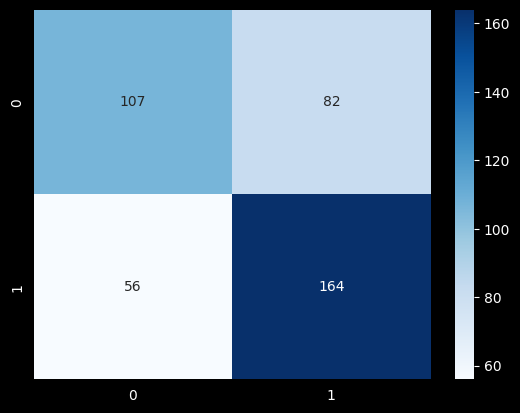

In [21]:
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)

        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.tolist())
        y_pred.extend(predicted.cpu().tolist())

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()